# **Machine Learning Analysis of Atmospheric CH₄ Time Series**

Following the previous analysis of atmospheric CO₂, this analysis applies a **machine learning approach** to atmospheric methane (CH₄) concentrations. The dataset contains **514 monthly observations from July 1983 to April 2026**, providing a long-term record of changes in atmospheric methane levels.

The analysis will investigate how different **machine learning methods** can be used to model and forecast the CH₄ time series. As with the previous analysis, the focus will be on understanding the structure of the data, developing suitable predictive features, training and tuning models, and evaluating their forecasting performance.

The analysis uses a **univariate time-series framework**, where the primary source of predictive information is the historical CH₄ concentration itself. The specific feature engineering, modelling approaches, and evaluation procedures will be introduced and discussed in the sections that follow.


## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [2]:
import pandas as pd

df = pd.read_csv("../data/ch4_mm_gl.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month   decimal  average  average_unc    trend  trend_unc
date                                                                       
1983-07-01  1983      7  1983.542  1626.05         2.39  1635.18       1.46
1983-08-01  1983      8  1983.625  1628.02         2.93  1635.67       1.39
1983-09-01  1983      9  1983.708  1638.42         2.20  1636.23       1.31
1983-10-01  1983     10  1983.792  1644.81         1.47  1636.85       1.23
1983-11-01  1983     11  1983.875  1642.60         0.82  1637.55       1.15


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [3]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1983-07-01 00:00:00 to 2024-04-01 00:00:00
Number of observations: 490

Holdout data:
2024-05-01 00:00:00 to 2026-04-01 00:00:00
Number of observations: 24


## **2. Data analysis**

### **2.1 Raw Series Inspection**
The raw monthly CH₄ series is plotted using the `average` concentration to identify its main time-series characteristics.

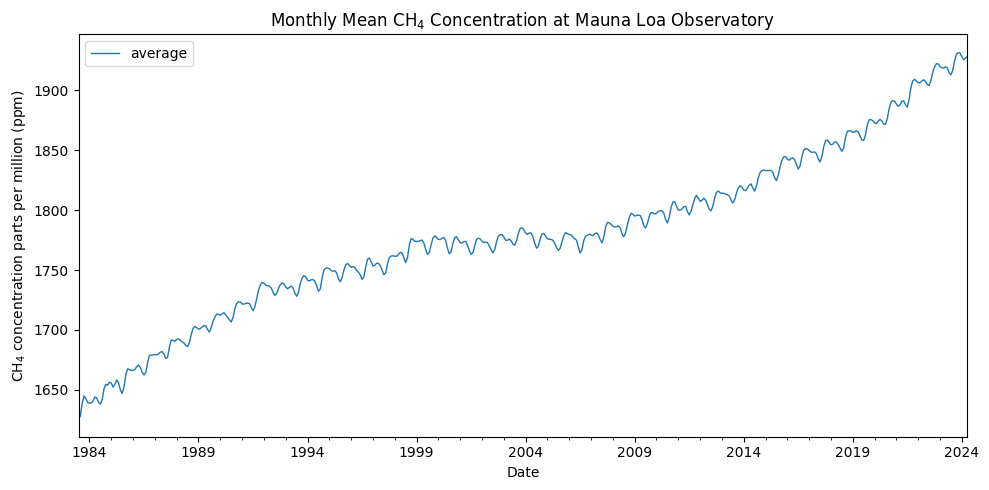

In [4]:
# Plot the raw series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly Mean CH$_4$ Concentration at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CH$_4$ concentration parts per million (ppm)")
plt.tight_layout()
plt.show()

### Raw CH₄ Time Series Analysis

The raw CH₄ series shows a clear **long-term upward trend** in atmospheric methane concentrations over the observation period. The series increases from approximately **1626 ppb in 1983 to values in the 1930s ppb by 2026**, indicating a substantial rise in atmospheric CH₄ over the last four decades. Alongside this long-term trend, the series exhibits a noticeable **seasonal pattern**, with concentrations regularly fluctuating throughout the year.

An interesting feature is the period between approximately **1999 and 2008**, during which the overall increase in CH₄ concentrations appears to temporarily slow or stabilize around **1770 ppb**. This period corresponds to the well-documented global methane growth plateau observed around the early 2000s. The slowdown has been associated with changes in methane emissions and variations in the atmospheric **OH sink**, which is an important mechanism for removing methane from the atmosphere. After this period, atmospheric CH₄ concentrations resumed their upward trajectory, with the increase becoming particularly pronounced in more recent years.

Overall, the raw series contains several prominent features: a **strong long-term trend, recurring seasonal variation, and a temporary period of near-stagnation**. These characteristics provide an important starting point for the subsequent analysis of the CH₄ time series.


### **2.2 Regular Differencing**

To reduce the **long-term trend** observed in the raw CH₄ series, regular first differencing is applied with a **lag of 1**. This calculates the month-to-month change in atmospheric methane concentration rather than modelling the concentration levels directly.

The differenced series is therefore defined as:

$$\Delta CH_{4,t} = CH_{4,t} - CH_{4,t-1}$$


This transformation removes the level component between consecutive observations and allows the resulting series to be examined separately from the original upward trend.


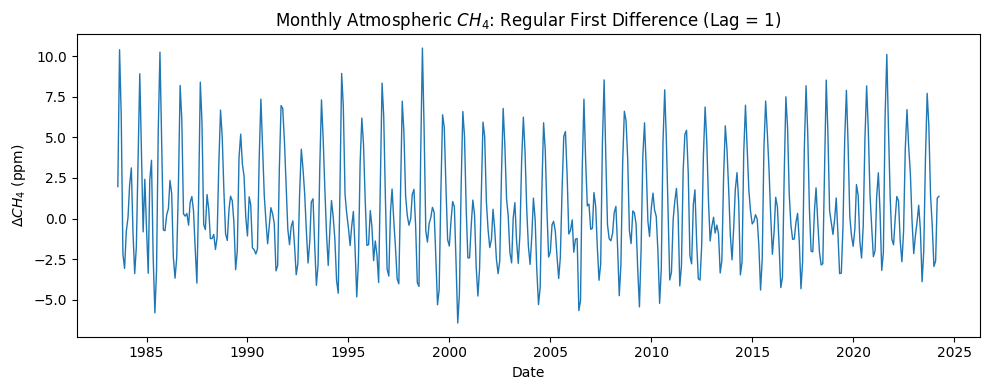

In [28]:
# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Monthly Atmospheric $CH_4$: Regular First Difference (Lag = 1)")
plt.xlabel("Date")
plt.ylabel(r"$\Delta CH_4$ (ppm)")
plt.tight_layout()
plt.show()

### **2.3 ACF and PACF of the Regularly Differenced Series**

After applying regular first differencing, we examine the **autocorrelation function (ACF)** and **partial autocorrelation function (PACF)** of the differenced $CH_4$ series.

The ACF shows how the differenced series is correlated with its previous values at different lags, while the PACF measures the correlation at each lag after accounting for the effects of shorter lags.


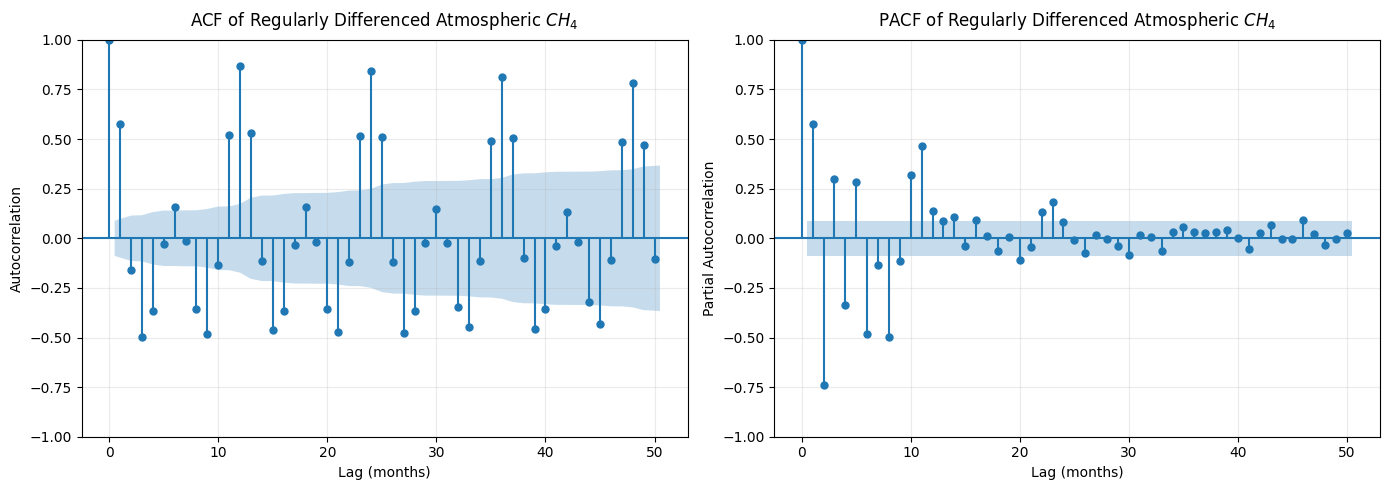

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Regularly differenced series
diff_regular = train["average"].diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ACF ---
plot_acf(diff_regular,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title("ACF of Regularly Differenced Atmospheric $CH_4$",fontsize=12,pad=10)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_regular,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title("PACF of Regularly Differenced Atmospheric $CH_4$",fontsize=12,pad=10)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


### Observations from the ACF and PACF

The ACF and PACF plots of the regularly differenced $CH_4$ series reveal several important patterns that will guide the feature-engineering stage.

#### ACF observations

The most prominent feature in the ACF is the strong **seasonal structure at multiples of 12 months**. Lag 1 shows a very strong and statistically significant positive correlation, while strong positive correlations also appear at lags **12, 24, 36, 48, and 60**. This suggests that, even after applying regular first differencing, the annual seasonal pattern remains clearly present in the $CH_4$ series.

An additional and interesting pattern is visible at lags separated by six months. Lags such as **3, 9, 15, 21, 27, 33, ...** show statistically significant negative autocorrelation. This indicates that the differenced series contains a repeating intra-year structure rather than simply a straightforward annual cycle. The alternating positive and negative correlations suggest that observations at certain positions within the seasonal cycle tend to move in opposite directions.

The ACF therefore suggests that the temporal information contained in previous observations is likely to be highly valuable for prediction.

#### PACF observations

The PACF provides a complementary view of the dependence structure. The first **12 lags contain several statistically significant partial autocorrelations**, with an alternating pattern in which strongly positive and negative coefficients occur at successive lags.

This indicates that the short-term dynamics of the differenced $CH_4$ series cannot be explained by a single previous observation alone. There appears to be meaningful dependence extending across several months, while the strong structure within the first 12 months is consistent with the seasonal behaviour identified in the ACF.

#### Implications for feature engineering

These results are particularly important because our dataset contains relatively few external explanatory variables. In a typical multivariate forecasting problem, information from variables such as temperature, precipitation, atmospheric pressure, emissions, or other environmental measurements could provide additional explanatory power. In our case, we therefore need to extract more predictive information from the **historical $CH_4$ series itself**.

The ACF and PACF provide empirical guidance for constructing these lagged features rather than selecting lags arbitrarily.

We will therefore consider several groups of lagged features:

- **Short-term lags:** lags such as 1, 2, 3, 4, 5, and 6 months to capture recent momentum and short-term dependence.
- **Within-year lags:** selected lags up to 12 months to capture the more detailed seasonal dynamics identified by the PACF.
- **Annual seasonal lags:** particularly lag 12, together with additional multiples such as 24, 36, 48, and 60 months, to capture persistence from previous years.
- **Three-month seasonal structure:** selected lags around the recurring 6-month pattern, including lags 3, 9, 15, 21, and so on, to investigate whether this apparent intra-year structure improves predictive performance.
- **Rolling and aggregated features:** rolling means, rolling standard deviations, and potentially other summaries of recent observations can provide information about the local level, variability, and trend of the series that a single lag cannot capture.

Importantly, the presence of significant autocorrelation does **not** mean that every significant lag should automatically become a feature. Including too many highly correlated lag variables can increase model complexity and introduce redundancy. Instead, the ACF/PACF findings will be used as a **data-informed starting point**, after which the usefulness of candidate features can be evaluated using time-series cross-validation and model performance.

Overall, the ACF and PACF suggest that the historical $CH_4$ observations contain substantial temporal and seasonal information. Feature engineering will therefore focus on transforming this temporal dependence into explanatory variables that allow the forecasting models to exploit patterns that would otherwise be difficult to capture given the limited number of external predictors.


### **2.4 Monthly Distribution of Differenced $CH_4$**

To further investigate the seasonal structure identified in the ACF, we examine the distribution of the **regularly differenced $CH_4$ series by calendar month**.

It is important to note that this boxplot does **not** show the absolute atmospheric $CH_4$ concentration for each month. Instead, it shows the distribution of the **month-to-month change in $CH_4$** for January, February, March, and so on.

This distinction is important when interpreting the results. A positive value indicates that $CH_4$ increased relative to the previous month, while a negative value indicates a decrease. The median and spread for each calendar month therefore allow us to investigate whether the magnitude and direction of monthly changes follow a recurring seasonal pattern.

This analysis complements the ACF and PACF results. Since regular first differencing did not remove the strong annual pattern observed in the ACF, we expect the distributions of the differenced series to exhibit systematic differences across calendar months. If particular months consistently show higher or lower median changes, or greater variability, this provides additional evidence that **calendar month and seasonal lag features may contain useful predictive information**.

The boxplot should therefore be interpreted as evidence of **seasonal behaviour in the changes of atmospheric $CH_4$**, rather than as evidence that atmospheric $CH_4$ concentrations themselves are highest or lowest in a particular month.


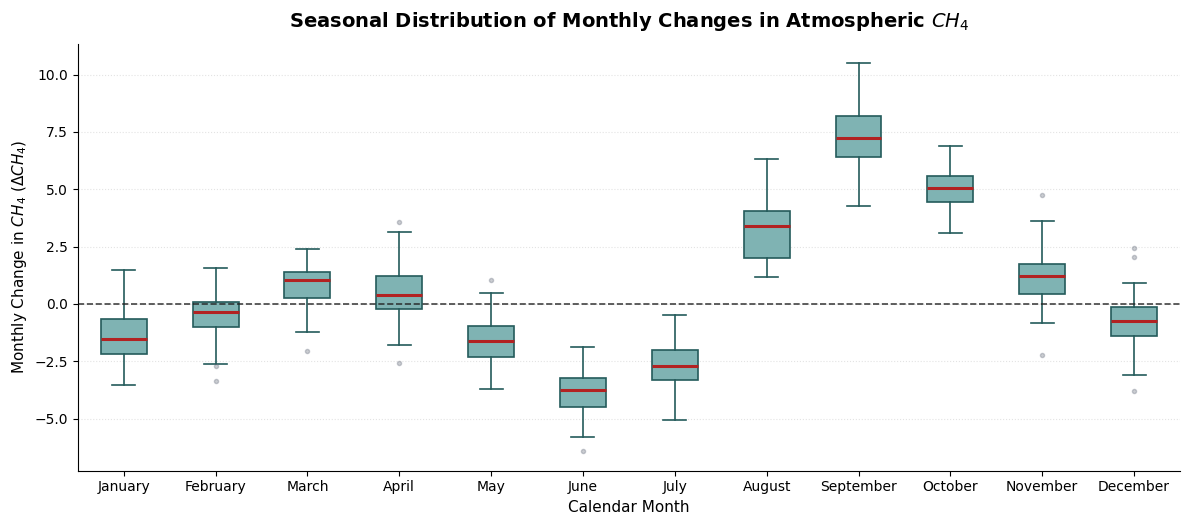

In [29]:
import calendar

# Prepare regularly differenced CH4 series
ch4_diff = train[["diff_regular"]].dropna().copy()

# Extract calendar month
ch4_diff["Month"] = ch4_diff.index.month_name()

# Preserve chronological order
month_order = list(calendar.month_name[1:])
ch4_diff["Month"] = pd.Categorical(
    ch4_diff["Month"],
    categories=month_order,
    ordered=True
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5.5))

ch4_diff.boxplot(
    column="diff_regular",
    by="Month",
    ax=ax,
    grid=False,
    patch_artist=True,
    boxprops=dict(
        facecolor="#7FB3B3",
        color="#245B5B",
        linewidth=1.2
    ),
    medianprops=dict(
        color="#B22222",
        linewidth=2.2
    ),
    whiskerprops=dict(
        color="#245B5B",
        linewidth=1.2
    ),
    capprops=dict(
        color="#245B5B",
        linewidth=1.2
    ),
    flierprops=dict(
        marker="o",
        markersize=3,
        markerfacecolor="#6B7280",
        markeredgecolor="#6B7280",
        alpha=0.35
    )
)

# Remove pandas automatic title
plt.suptitle("")

# Zero reference line
ax.axhline(
    0,
    color="#222222",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85
)

# Titles and labels
ax.set_title(
    r"Seasonal Distribution of Monthly Changes in Atmospheric $CH_4$",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Calendar Month",
    fontsize=11
)

ax.set_ylabel(
    r"Monthly Change in $CH_4$ ($\Delta CH_4$)",
    fontsize=11
)

# Grid
ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.8,
    alpha=0.35
)

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [30]:
# Numerical statistics for the regularly differenced CH4 series by month

monthly_stats = (
    ch4_diff
    .groupby("Month", observed=True)["diff_regular"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max"
    )
)

# Add interquartile range (IQR)
monthly_stats["IQR"] = monthly_stats["q3"] - monthly_stats["q1"]

# Display rounded results
monthly_stats.round(4)


,count,mean,median,std,min,q1,q3,max,IQR
Month,,,,,,,,,
January,41,-1.4468,-1.55,1.1245,-3.54,-2.2000,-0.6500,1.48,1.5500
February,41,-0.4466,-0.35,1.0561,-3.37,-1.0300,0.0800,1.57,1.1100
March,41,0.7971,1.02,1.0068,-2.07,0.2400,1.3800,2.38,1.1400
April,41,0.4822,0.39,1.3203,-2.59,-0.2100,1.2200,3.59,1.4300
May,40,-1.5457,-1.62,1.0825,-3.71,-2.2975,-0.9650,1.06,1.3325
June,40,-3.8490,-3.75,1.0996,-6.43,-4.4875,-3.2125,-1.87,1.2750
July,40,-2.7360,-2.72,1.1386,-5.05,-3.3200,-2.0100,-0.48,1.3100
August,41,3.2151,3.38,1.2215,1.18,2.0100,4.0300,6.31,2.0200
September,41,7.3459,7.24,1.4772,4.27,6.3900,8.2000,10.50,1.8100


### Discussion of the Monthly Differenced $CH_4$ Distribution

The monthly boxplots provide another view of the seasonal structure identified in the ACF and PACF analysis. Because the series has been regularly differenced, the distributions represent **month-to-month changes in atmospheric $CH_4$**, rather than the absolute concentration of $CH_4$.

A clear seasonal pattern is visible across the calendar year. From **January through April**, the distributions remain relatively close to the zero line, although March and April show a shift toward positive changes. A pronounced negative movement then appears in **May and June**, with June showing the strongest negative median change of approximately **−3.75**. The changes remain negative in July, although the magnitude begins to weaken.

The pattern then reverses strongly during **August and September**. August has a positive median change of approximately **+3.38**, while September shows the largest positive median change of approximately **+7.24**. The increase remains positive in October, with a median of approximately **+5.06**, before weakening substantially in November and returning to a negative median in December.

Overall, the most pronounced departures from zero occur between approximately **May and October**. This six-month period contains the strongest seasonal movement in the differenced series: a decline from May through June and July, followed by a strong increase from August through September and October. This is consistent with the strong seasonal structure observed in the ACF and suggests that the differenced $CH_4$ series is not behaving as a purely stationary series with only short-term dependence; a substantial within-year seasonal component remains.

#### Why is September particularly variable?

September has both the **largest positive median change** and a relatively large spread compared with most other months. The IQR is approximately **1.81**, compared with values closer to 1–1.5 for many other months. This indicates that the magnitude of the September increase varies considerably from year to year.

This variation can be associated with the seasonal nature of atmospheric methane. Methane concentrations are influenced by the combined effects of **seasonal emissions, atmospheric transport, and atmospheric removal processes**. Natural sources such as wetlands respond to temperature and hydrological conditions, while anthropogenic sources such as agriculture, livestock, waste, and energy production can also contribute to seasonal changes. The atmospheric sink, particularly oxidation by hydroxyl radicals (OH), also varies seasonally.

Therefore, the large September spread should be interpreted as evidence that the strength of the seasonal increase is not identical every year. Different environmental and atmospheric conditions can amplify or weaken the observed change.

#### Relationship with the six-month pattern

The May–October behaviour is also interesting in relation to the approximately **six-month structure** suggested by the lag analysis. The series moves from strongly negative changes in June toward strongly positive changes in September, creating a broad reversal over roughly half a year.

However, the boxplot alone cannot establish that a six-month seasonal cycle is responsible. Instead, it provides supporting visual evidence for a **within-year seasonal oscillation**. The ACF and PACF provide the stronger statistical evidence for the temporal structure, while the monthly boxplots show how that structure manifests across the calendar year.

Together, these findings suggest that the feature-engineering stage should capture both **short-term dependence and seasonal dependence**. In particular, the strong annual pattern motivates the inclusion of 12-month seasonal lags, while the observed six-month reversal motivates investigating shorter seasonal relationships such as lag 6. The ACF results can then be used to determine whether additional lags around these seasonal intervals provide useful predictive information.

Importantly, these features should be treated as candidate predictors rather than automatically included in the final model. Their usefulness will ultimately be evaluated using time-series cross-validation to determine whether the seasonal information improves out-of-sample forecasting performance.


## **3. Feature Engineering for Machine Learning**

The target variable is the observed monthly atmospheric methane concentration, represented by `average`. The forecasting task is therefore a **regression problem**, where the objective is to use previously observed information to predict the $CH_4$ concentration for a future month.

Unlike a conventional multivariate regression problem, this dataset contains relatively few external explanatory variables. We therefore need to extract additional predictive information from the historical behaviour of the $CH_4$ series itself. The exploratory analysis of the differenced series provides a basis for selecting these features.

The ACF showed particularly strong dependence at **lag 1** and at multiples of **12 months**, while an additional pattern of negative correlations was observed around lags separated by three months. The PACF also showed significant dependence across much of the first 12 lags. The monthly boxplots further revealed a strong within-year pattern, with pronounced changes occurring between approximately May and October and a reversal from strongly negative changes around June toward strongly positive changes around September.

Consequently, the feature-engineering strategy will focus on four groups of predictors:

1. **Cyclical calendar features** to represent the annual seasonal position.
2. **Targeted lag features** selected from the ACF and PACF findings rather than using an arbitrary collection of lags.
3. **Rolling statistics** to describe the recent level and variability of atmospheric $CH_4$.
4. **Lagged change features** to provide the models with information about recent increases or decreases in methane concentration.

### Target Variable

The target variable is:

$$
\text{Target}_t = CH_4(t)
$$

where `average` represents the observed monthly mean atmospheric $CH_4$ concentration.

The target is kept in its original level form because the machine learning models will directly predict the methane concentration for the next month.

### Cyclical Month Features

Calendar month contains important seasonal information. However, treating month as an ordinary numerical variable would incorrectly imply that December (`12`) and January (`1`) are far apart.

We therefore encode the annual cycle using sine and cosine transformations:

$$
\text{month\_sin}
=
\sin\left(\frac{2\pi \cdot \text{month}}{12}\right)
$$

$$
\text{month\_cos}
=
\cos\left(\frac{2\pi \cdot \text{month}}{12}\right)
$$

These features allow the models to represent the continuous transition from one calendar year into the next.

We retain the calendar month information because the monthly boxplot showed that the magnitude and direction of $CH_4$ changes differ substantially across the year.

### Targeted Lag Features

Rather than creating a large arbitrary set of lagged observations, the lag structure is guided by the ACF and PACF results.

The first group consists of **short-term lags**:

- `lag_1`
- `lag_2`
- `lag_3`

Lag 1 is particularly important because it showed the strongest short-term positive autocorrelation in the ACF. Lags 2 and 3 allow the models to capture the immediate multi-month dynamics.

The second group captures the **within-year structure** identified by the PACF and ACF:

- `lag_6`
- `lag_9`
- `lag_12`

Lag 6 is included because the monthly analysis suggested a broad approximately six-month reversal in the differenced series. Lag 9 is included because the ACF showed a recurring negative pattern around lags separated by three months. Lag 12 represents the most important annual seasonal relationship.

The third group captures **longer-term annual persistence**:

- `lag_24`
- `lag_36`
- `lag_48`
- `lag_60`

These allow the models to compare the current prediction period with observations from one, two, three, four, and five years earlier. The inclusion of these longer lags is motivated by the repeated positive ACF pattern at multiples of 12 months.

The selected lag structure is therefore deliberately designed around the observed temporal behaviour rather than simply including every possible lag.

### Lagged Change Features

Because the analysis of the regularly differenced series revealed strong patterns in the direction and magnitude of monthly changes, we also create lagged changes in $CH_4$.

These features describe whether the series was recently increasing or decreasing and by how much. For example, a lagged first difference represents the change that occurred between the previous two observations.

These features provide information that is related to the momentum of the series while avoiding leakage from the current target.

### Rolling Features

Rolling statistics are used to provide information about the recent level and variability of the methane series.

We include rolling windows representing approximately:

- **3 months** — short-term behaviour;
- **6 months** — the approximate half-year seasonal structure;
- **12 months** — the annual seasonal cycle.

For each window, rolling mean and rolling standard deviation are calculated using **previous observations only**.

For example:

$$
\text{RollingMean}_{12,t}
=
\frac{1}{12}
\sum_{i=1}^{12} CH_4(t-i)
$$

The current observation is deliberately excluded from every rolling calculation. This is essential because the current observation is the value that the model is attempting to predict.

### Seasonal Change Features

The ACF indicates strong persistence at 12-month intervals. We therefore also create lagged seasonal-change information based only on observations that would have been available before the prediction point.

For example, a lagged 12-month change can be constructed from previously observed values rather than calculating:

$$
CH_4(t)-CH_4(t-12)
$$

directly as a predictor, because that expression contains the current target $CH_4(t)$ and would therefore cause leakage.

Instead, the feature is constructed from earlier observations, allowing the model to learn whether the series was recently above or below its corresponding seasonal level.

### Avoiding Data Leakage

All engineered predictors must represent information that would have been available **at the time the prediction was made**.

For this reason:

- lagged features use only previous observations;
- rolling statistics are shifted before the rolling calculation;
- current target values are never used to construct their own predictors;
- no future observations are used to calculate features;
- the 24-month holdout period is not used to fit, select, or tune the model.

The feature-engineering process is implemented as a reusable function so that the same transformations can be applied consistently during model development and forecasting.

The final feature set is therefore intentionally more targeted than the original generic approach. It combines **short-term persistence, intra-year dynamics, annual seasonality, longer-term seasonal persistence, calendar effects, recent changes, and rolling behaviour**. This allows the machine learning models to extract explanatory information from the historical $CH_4$ series despite the limited number of external predictors.


In [38]:
import numpy as np
import pandas as pd


def create_ch4_features(df, target_col="average"):
    """
    Create machine-learning features for monthly atmospheric CH4.

    All lagged and rolling features use information from previous
    observations only, preventing target leakage.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by date and containing the target column.
    target_col : str
        Name of the CH4 concentration column.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing target and engineered features.
    """

    data = train.copy()

    # ---------------------------------------------------------
    # 1. Calendar features
    # ---------------------------------------------------------

    data["month"] = data.index.month

    # Cyclical representation of the annual calendar
    data["month_sin"] = np.sin(
        2 * np.pi * data["month"] / 12
    )

    data["month_cos"] = np.cos(
        2 * np.pi * data["month"] / 12
    )

    # ---------------------------------------------------------
    # 2. Targeted lag features
    # ---------------------------------------------------------

    # Selected based on ACF/PACF analysis
    selected_lags = [
        1, 3, 9,       # short-term dependence
        12, 15, 21,      # within-year / seasonal structure
        24, 27, 33,
        36              # longer-term annual persistence
    ]

    for lag in selected_lags:
        data[f"lag_{lag}"] = data[target_col].shift(lag)

    # ---------------------------------------------------------
    # 3. Lagged change features
    # ---------------------------------------------------------

    # First difference at previous time points
    data["diff_lag_1"] = (
        data[target_col].shift(1)
        - data[target_col].shift(2)
    )

    data["diff_lag_3"] = (
        data[target_col].shift(3)
        - data[target_col].shift(4)
    )

    data["diff_lag_6"] = (
        data[target_col].shift(6)
        - data[target_col].shift(7)
    )

    data["diff_lag_12"] = (
        data[target_col].shift(12)
        - data[target_col].shift(13)
    )

    # ---------------------------------------------------------
    # 4. Lagged seasonal-change features
    # ---------------------------------------------------------

    # Difference between a previous observation and the
    # corresponding observation one year earlier.
    #
    # IMPORTANT:
    # These use only historical values and therefore do not
    # contain the current target.

    data["seasonal_diff_lag_1"] = (
        data[target_col].shift(1)
        - data[target_col].shift(13)
    )

    data["seasonal_diff_lag_6"] = (
        data[target_col].shift(6)
        - data[target_col].shift(18)
    )

    data["seasonal_diff_lag_12"] = (
        data[target_col].shift(12)
        - data[target_col].shift(24)
    )

    # ---------------------------------------------------------
    # 5. Rolling statistics
    # ---------------------------------------------------------

    # Shift first so that the current target is never included
    # in its own rolling features.

    shifted_target = data[target_col].shift(1)

    rolling_windows = [3, 6, 12]

    for window in rolling_windows:

        data[f"rolling_mean_{window}"] = (
            shifted_target
            .rolling(window=window)
            .mean()
        )

        data[f"rolling_std_{window}"] = (
            shifted_target
            .rolling(window=window)
            .std()
        )

    # ---------------------------------------------------------
    # 6. Recent trend features
    # ---------------------------------------------------------

    # Difference between recent rolling means.
    # These describe whether the recent CH4 level is rising
    # or falling without using the current target.

    data["trend_3_6"] = (
        data["rolling_mean_3"]
        - data["rolling_mean_6"]
    )

    data["trend_6_12"] = (
        data["rolling_mean_6"]
        - data["rolling_mean_12"]
    )

    # ---------------------------------------------------------
    # 7. Remove rows with insufficient history
    # ---------------------------------------------------------

    # The largest lag is 60 months, so the first 60 rows cannot
    # contain a complete set of engineered predictors.

    data = data.dropna().copy()

    return data


In [40]:
# Create engineered CH4 dataset
ch4_features = create_ch4_features(train, target_col="average")

# Separate predictors and target
X = ch4_features.drop(columns=["average"])
y = ch4_features["average"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())


Feature matrix shape: (454, 34)
Target shape: (454,)

Feature names:
['year', 'month', 'decimal', 'average_unc', 'trend', 'trend_unc', 'diff_regular', 'month_sin', 'month_cos', 'lag_1', 'lag_3', 'lag_9', 'lag_12', 'lag_15', 'lag_21', 'lag_24', 'lag_27', 'lag_33', 'lag_36', 'diff_lag_1', 'diff_lag_3', 'diff_lag_6', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_6', 'seasonal_diff_lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'trend_3_6', 'trend_6_12']


## 2. **Leakage-Free Feature Engineering for Machine Learning**

The objective of feature engineering is to transform the univariate monthly $CH_4$ time series into a supervised learning dataset while preserving the chronological forecasting structure.

The target is:

$$
y_t = CH_4(t)
$$

When predicting $y_t$, the model is assumed to have access to observations only up to $t-1$. Therefore, every predictor must be constructed exclusively from historical observations:

$$
X_t = f(y_{t-1},y_{t-2},\ldots,y_{t-k},\text{calendar information})
$$

The current $CH_4$ observation $y_t$ must never be used to construct a predictor for itself.

### Calendar Features

Calendar information is known in advance and can therefore be used directly. We retain:

- `year`
- `month`
- `decimal`
- `month_sin`
- `month_cos`

The cyclical month features represent the annual seasonal cycle while preserving the fact that December and January are adjacent points in time.

### Lag Features

The ACF and PACF analysis showed particularly strong temporal structure at lag 1, annual multiples of 12, and several intermediate lags.

Rather than using an arbitrary collection of consecutive lags, the feature set therefore emphasizes the lags identified during the time-series analysis:

$$
1,3,9,12,15,21,24,27,33,36
$$

For example:

$$
lag_1(t)=y_{t-1}
$$

and

$$
lag_{12}(t)=y_{t-12}
$$

All lag features are based strictly on observations available before the prediction month.

### Lagged Change Features

Changes in $CH_4$ are also potentially informative. However, the current first difference

$$
y_t-y_{t-1}
$$

cannot be used because it contains the target $y_t$.

Instead, the change features are deliberately shifted:

$$
\Delta_{1}(t)=y_{t-1}-y_{t-2}
$$

Thus, the model can know whether $CH_4$ was increasing or decreasing during the previous month without seeing the current observation.

### Seasonal Difference Features

Seasonal changes are similarly constructed entirely from historical observations.

For example:

$$
SD_{1}(t)=y_{t-1}-y_{t-13}
$$

compares the previous month with the corresponding month one year earlier.

This allows the model to capture annual changes without using the current target.

### Rolling Features

Rolling statistics provide information about recent level and variability.

To avoid leakage, the target series is shifted by one month **before** calculating the rolling statistics.

For example:

$$
RollingMean_3(t)
=
\frac{
y_{t-1}+y_{t-2}+y_{t-3}
}{3}
$$

Therefore, the rolling features describe the recent history available immediately before month $t$.

The same principle is applied to rolling standard deviations.

### Recent Trend Features

Recent trend features are calculated from the historical rolling means:

$$
Trend_{3,6}(t)
=
RollingMean_3(t)-RollingMean_6(t)
$$

and

$$
Trend_{6,12}(t)
=
RollingMean_6(t)-RollingMean_{12}(t)
$$

These features provide the models with information about whether the recent $CH_4$ level is changing relative to a longer historical window.

### Explicit Leakage Prevention

Several variables from the original dataset are deliberately excluded from the machine-learning predictors.

`average_unc`, `trend`, and `trend_unc` are not used because their temporal availability and construction do not form part of the forecasting feature definition.

Most importantly, `diff_regular` is excluded because:

$$
diff\_regular(t)=y_t-y_{t-1}
$$

which means it directly contains the target value.

The resulting feature matrix therefore contains only calendar variables and historical information that would genuinely be available when forecasting the next monthly $CH_4$ observation.

The final dataset is then used consistently across all candidate machine-learning models.


In [154]:
import numpy as np
import pandas as pd


def create_ch4_features(df, target_col="average"):
    """
    Create leakage-free machine-learning features for
    monthly atmospheric CH4 forecasting.

    Every predictor for time t is constructed using information
    available at t-1 or earlier.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by date and containing the target.
    target_col : str
        Name of the CH4 concentration column.

    Returns
    -------
    pandas.DataFrame
        Target plus leakage-free engineered predictors.
    """

    # ---------------------------------------------------------
    # 0. Copy the DATAFRAME PASSED to the function
    # ---------------------------------------------------------

    data = df.copy()

    # Ensure chronological order
    data = data.sort_index()

    # ---------------------------------------------------------
    # 1. Calendar features
    # ---------------------------------------------------------

    data["year"] = data.index.year

    data["month"] = data.index.month

    # Decimal year representation
    data["decimal"] = (
        data.index.year
        + (data.index.month - 1) / 12
    )

    # Cyclical representation of annual seasonality
    data["month_sin"] = np.sin(
        2 * np.pi * data["month"] / 12
    )

    data["month_cos"] = np.cos(
        2 * np.pi * data["month"] / 12
    )

    # ---------------------------------------------------------
    # 2. ACF/PACF-informed lag features
    # ---------------------------------------------------------

    # Selected from the observed temporal structure.
    #
    # lag 1:
    # strong short-term persistence
    #
    # 12, 24, 36:
    # annual / multi-annual persistence
    #
    # 3, 9, 15, 21, 27, 33:
    # lags highlighted by the ACF/PACF structure

    selected_lags = [
        1,
        2,
        3,
        9,
        12,
        15,
        21,
        24,
        27,
        33,
        36
    ]

    for lag in selected_lags:

        data[f"lag_{lag}"] = (
            data[target_col].shift(lag)
        )

    # ---------------------------------------------------------
    # 3. Historical change features
    # ---------------------------------------------------------

    # IMPORTANT:
    #
    # These are NOT:
    #
    # y(t) - y(t-1)
    #
    # because that would contain the target.
    #
    # Instead they use historical observations only.

    data["diff_lag_1"] = (
        data[target_col].shift(1)
        - data[target_col].shift(2)
    )
    data["diff_lag_2"] = (
        data[target_col].shift(2)
        - data[target_col].shift(3)
    )

    data["diff_lag_3"] = (
        data[target_col].shift(3)
        - data[target_col].shift(4)
    )

    data["diff_lag_6"] = (
        data[target_col].shift(6)
        - data[target_col].shift(7)
    )

    data["diff_lag_12"] = (
        data[target_col].shift(12)
        - data[target_col].shift(13)
    )

    # ---------------------------------------------------------
    # 4. Historical seasonal differences
    # ---------------------------------------------------------

    # These compare historical observations with the
    # corresponding observations one year earlier.
    #
    # No current target is used.

    data["seasonal_diff_lag_1"] = (
        data[target_col].shift(1)
        - data[target_col].shift(13)
    )
    data["seasonal_diff_lag_2"] = (
        data[target_col].shift(2)
        - data[target_col].shift(14)
    )
    data["seasonal_diff_lag_3"] = (
        data[target_col].shift(3)
        - data[target_col].shift(15)
    )

    data["seasonal_diff_lag_6"] = (
        data[target_col].shift(6)
        - data[target_col].shift(18)
    )

    data["seasonal_diff_lag_12"] = (
        data[target_col].shift(12)
        - data[target_col].shift(24)
    )

    # ---------------------------------------------------------
    # 5. Leakage-free rolling statistics
    # ---------------------------------------------------------

    # Shift BEFORE rolling.
    #
    # Therefore, rolling statistics at time t contain:
    #
    # t-1, t-2, ..., t-window
    #
    # and NEVER t.

    shifted_target = (
        data[target_col]
        .shift(1)
    )

    rolling_windows = [
        1,
        2,
        3,
        6,
        12
    ]

    for window in rolling_windows:

        data[f"rolling_mean_{window}"] = (
            shifted_target
            .rolling(
                window=window,
                min_periods=window
            )
            .mean()
        )

        data[f"rolling_std_{window}"] = (
            shifted_target
            .rolling(
                window=window,
                min_periods=window
            )
            .std()
        )

    # ---------------------------------------------------------
    # 6. Historical trend features
    # ---------------------------------------------------------

    data["trend_1_2"] = (
        data["rolling_mean_1"]
        - data["rolling_mean_2"]
    )
    data["trend_2_3"] = (
        data["rolling_mean_2"]
        - data["rolling_mean_3"]
    )
    data["trend_3_6"] = (
        data["rolling_mean_3"]
        - data["rolling_mean_6"]
    )

    data["trend_6_12"] = (
        data["rolling_mean_6"]
        - data["rolling_mean_12"]
    )

    # ---------------------------------------------------------
    # 7. Explicitly select ONLY intended variables
    # ---------------------------------------------------------

    feature_columns = [

        # Calendar
        "year",
        "month",
        "decimal",
        "month_sin",
        "month_cos",

        # ACF/PACF-informed lags
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_9",
        "lag_12",
        "lag_15",
        "lag_21",
        "lag_24",
        "lag_27",
        "lag_33",
        "lag_36",

        # Historical changes
        "diff_lag_1",
        "diff_lag_2",
        "diff_lag_3",
        "diff_lag_6",
        "diff_lag_12",

        # Historical seasonal changes
        "seasonal_diff_lag_1",
        "seasonal_diff_lag_2",
        "seasonal_diff_lag_6",
        "seasonal_diff_lag_12",

        # Historical rolling statistics
        "rolling_mean_3",
        "rolling_std_3",
        "rolling_mean_6",
        "rolling_std_6",
        "rolling_mean_12",
        "rolling_std_12",

        # Historical trend
        "trend_1_2",
        "trend_2_3",
        "trend_3_6",
        "trend_6_12"
    ]

    # Keep target + intended predictors only
    data = data[
        [target_col] + feature_columns
    ].copy()

    # ---------------------------------------------------------
    # 8. Remove rows without sufficient historical information
    # ---------------------------------------------------------

    # The longest required history is 36 months.
    #
    # Rows before sufficient history exists cannot be used
    # because their engineered predictors contain NaN values.

    data = data.dropna().copy()

    return data


In [155]:
# ============================================================
# Create leakage-free CH4 feature matrix
# ============================================================

ch4_features = create_ch4_features(
    train,
    target_col="average"
)


# ============================================================
# Separate predictors and target
# ============================================================

X = ch4_features.drop(
    columns=["average"]
)

y = ch4_features["average"]


print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())


Feature matrix shape: (454, 35)
Target shape: (454,)

Feature names:
['year', 'month', 'decimal', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_9', 'lag_12', 'lag_15', 'lag_21', 'lag_24', 'lag_27', 'lag_33', 'lag_36', 'diff_lag_1', 'diff_lag_2', 'diff_lag_3', 'diff_lag_6', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_2', 'seasonal_diff_lag_6', 'seasonal_diff_lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'trend_1_2', 'trend_2_3', 'trend_3_6', 'trend_6_12']


In [156]:
X = ch4_features.drop(
    columns=[
        "average",
        "year",
        "decimal",
        "lag_12",
        "lag_9",
        "lag_15",
        "lag_21",
        "lag_24",
        "lag_27",
        "lag_33",
        "lag_36",
        "rolling_std_3",
        "rolling_mean_6",
        "rolling_std_6",
        "rolling_mean_12",
        "rolling_std_12",
        "diff_lag_6",
        "seasonal_diff_lag_6",
        "seasonal_diff_lag_12",
        "trend_6_12"
    ]
)

y = ch4_features["average"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nRemaining features:")
print(X.columns.tolist())


Feature matrix shape: (454, 16)
Target shape: (454,)

Remaining features:
['month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'diff_lag_1', 'diff_lag_2', 'diff_lag_3', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_2', 'rolling_mean_3', 'trend_1_2', 'trend_2_3', 'trend_3_6']


In [157]:
# ============================================================
# LEAKAGE CHECK 1
# Does any feature contain the current target exactly?
# ============================================================

print("=" * 70)
print("CHECKING FOR EXACT TARGET RECONSTRUCTION")
print("=" * 70)

for feature in X.columns:

    correlation = X[feature].corr(y)

    print(
        f"{feature:25s} "
        f"correlation = {correlation: .6f}"
    )


CHECKING FOR EXACT TARGET RECONSTRUCTION
month                     correlation = -0.000259
month_sin                 correlation =  0.032733
month_cos                 correlation =  0.065976
lag_1                     correlation =  0.998567
lag_2                     correlation =  0.995421
lag_3                     correlation =  0.992659
diff_lag_1                correlation =  0.085237
diff_lag_2                correlation =  0.080692
diff_lag_3                correlation =  0.057248
diff_lag_12               correlation =  0.040601
seasonal_diff_lag_1       correlation =  0.216689
seasonal_diff_lag_2       correlation =  0.212806
rolling_mean_3            correlation =  0.996382
trend_1_2                 correlation =  0.085237
trend_2_3                 correlation =  0.090797
trend_3_6                 correlation =  0.097257


In [158]:
print("\n" + "=" * 70)
print("CURRENT FEATURE SET")
print("=" * 70)

print(X.columns.tolist())

print("\nIs diff_regular present?")
print("diff_regular" in X.columns)

print("\nIs average_unc present?")
print("average_unc" in X.columns)

print("\nIs trend present?")
print("trend" in X.columns)

print("\nIs trend_unc present?")
print("trend_unc" in X.columns)



CURRENT FEATURE SET
['month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'diff_lag_1', 'diff_lag_2', 'diff_lag_3', 'diff_lag_12', 'seasonal_diff_lag_1', 'seasonal_diff_lag_2', 'rolling_mean_3', 'trend_1_2', 'trend_2_3', 'trend_3_6']

Is diff_regular present?
False

Is average_unc present?
False

Is trend present?
False

Is trend_unc present?
False


In [159]:
# ============================================================
# Verify rolling mean construction
# ============================================================

check_date = ch4_features.index[10]

print("Date being predicted:")
print(check_date)

print("\nCurrent CH4:")
print(train.loc[check_date, "average"])

print("\nPrevious 3 CH4 observations:")

previous_values = train.loc[
    train.index < check_date,
    "average"
].tail(3)

print(previous_values)

print("\nExpected rolling mean:")
print(previous_values.mean())

print("\nFeature rolling_mean_3:")
print(
    ch4_features.loc[
        check_date,
        "rolling_mean_3"
    ]
)


Date being predicted:
1987-05-01 00:00:00

Current CH4:
1681.85

Previous 3 CH4 observations:
date
1987-02-01    1679.02
1987-03-01    1680.01
1987-04-01    1681.37
Freq: MS, Name: average, dtype: float64

Expected rolling mean:
1680.1333333333332

Feature rolling_mean_3:
1680.1333333333332


# 3. **Linear Regression Models**

The first modelling stage uses a family of linear regression models. These models provide an interpretable baseline and allow us to evaluate how much of the monthly atmospheric $CH_4$ variation can be explained using the engineered temporal and seasonal features.

This is particularly useful for our dataset because the feature-engineering analysis has produced a relatively rich set of predictors despite the limited number of external explanatory variables. The predictors include lagged $CH_4$ concentrations, lagged changes, seasonal lags, rolling statistics, calendar features, and cyclical month variables.

## 3.1 Ordinary Least Squares Linear Regression

Ordinary Least Squares (OLS) provides the simplest baseline:

$$
\hat{y}_t =
\beta_0 +
\beta_1 X_{1,t} +
\beta_2 X_{2,t} +
\cdots +
\beta_p X_{p,t}
$$

The coefficients are estimated by minimizing the sum of squared residuals:

$$
\min_{\beta}
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
$$

OLS is useful as a baseline because it provides a direct measure of how well a linear relationship between the engineered features and future $CH_4$ concentration performs.

However, the engineered feature matrix contains substantial **multicollinearity**. For example, several lagged observations are related to one another, while rolling means and seasonal differences are also derived from the same underlying $CH_4$ series. This can make OLS coefficient estimates unstable even when predictive performance remains reasonable.

For this reason, OLS will be treated primarily as a benchmark against which regularized linear models can be compared.

## 3.2 Ridge Regression

Ridge regression extends OLS by adding an $L_2$ penalty to the coefficient estimates:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\alpha\sum_{j=1}^{p}\beta_j^2
\right]
$$

The parameter $\alpha$ controls the strength of regularization. Larger values shrink coefficients more strongly toward zero.

Ridge is particularly appropriate for this problem because many of our lagged and rolling features are likely to be correlated. Rather than allowing correlated predictors to produce unstable coefficient estimates, Ridge distributes their influence more smoothly.

The Ridge hyperparameter $\alpha$ will therefore be tuned using expanding-window time-series cross-validation.

## 3.3 Lasso Regression

Lasso uses an $L_1$ penalty:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\alpha\sum_{j=1}^{p}|\beta_j|
\right]
$$

Unlike Ridge, the Lasso penalty can shrink some coefficients exactly to zero. This effectively performs feature selection.

Lasso is useful here because we have 34 engineered features, several of which may contain overlapping information. A successful Lasso model could indicate that only a smaller subset of the engineered features is necessary for prediction.

However, when predictors are strongly correlated, Lasso can behave unpredictably by selecting one variable from a group of correlated predictors while excluding another similar variable. Therefore, Lasso will be compared directly with Ridge rather than assumed to be superior.

## 3.4 Elastic Net

Elastic Net combines the $L_1$ and $L_2$ penalties:

$$
\min_{\beta}
\left[
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
+
\alpha
\left(
\rho\sum_{j=1}^{p}|\beta_j|
+
(1-\rho)\sum_{j=1}^{p}\beta_j^2
\right)
\right]
$$

where $\alpha$ controls the overall regularization strength and $\rho$ controls the balance between the Lasso and Ridge penalties.

Elastic Net is particularly useful when there are groups of correlated predictors, as is expected in our lagged feature set. It can retain groups of related variables while still encouraging unnecessary features toward zero.

## Time-Series Validation and Hyperparameter Tuning

Random train-test splitting or ordinary random K-fold cross-validation will not be used. Such approaches could allow observations from later periods to influence the model while evaluating earlier periods, which would violate the temporal structure of the forecasting problem.

Instead, model selection will use **expanding-window validation**. In each validation fold, the model is trained using observations from the beginning of the series up to a particular point and then evaluated on the immediately following observations.

Conceptually:

$$
\text{Train}_1
\rightarrow
\text{Validation}_1
$$

$$
\text{Train}_1+\text{Validation}_1
\rightarrow
\text{Validation}_2
$$

and so forth.

This better represents the actual forecasting situation because the model is always trained using information that occurred before the observations being predicted.

For Ridge, Lasso, and Elastic Net, hyperparameters will be selected using the mean validation error across the expanding folds. Feature scaling will be performed within each validation split using a `Pipeline`, ensuring that the scaler is fitted only on the training portion of each fold.

The primary evaluation metrics will be:

- **MAE (Mean Absolute Error):** average absolute forecasting error and an easily interpretable measure of prediction accuracy.
- **RMSE (Root Mean Squared Error):** penalizes larger errors more heavily than MAE.
- **$R^2$:** measures the proportion of variance explained relative to a constant-mean baseline.
- **MAPE (Mean Absolute Percentage Error):** expresses the error as a percentage of the observed value. Because atmospheric $CH_4$ concentrations are strictly positive and far from zero, MAPE is usable here, although it will not be treated as the primary metric.

The final model comparison will be based primarily on out-of-sample MAE and RMSE, while $R^2$ and MAPE provide additional perspectives on performance.


In [160]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. Prepare X and y
# ============================================================

# ch4_features was created during feature engineering
# and contains only rows with complete engineered features.

#X = ch4_features.drop(columns=["average"]).copy()
X = ch4_features.drop(
    columns=[
        "average",
        "year",
        "decimal",
        "lag_3",
        "lag_9",
        "lag_12",
        "lag_15",
        "lag_21",
        "lag_24",
        "lag_27",
        "lag_33",
        "lag_36",
        "rolling_mean_3",
        "rolling_std_3",
        "rolling_mean_6",
        "rolling_std_6",
        "rolling_mean_12",
        "rolling_std_12",
        "diff_lag_6",
        "seasonal_diff_lag_6",
        "seasonal_diff_lag_12",
        "trend_6_12"
       
    ]
)
y = ch4_features["average"].copy()


# ============================================================
# 2. Chronological train/validation structure
# ============================================================

# IMPORTANT:
# This is NOT random K-fold CV.
#
# Each fold trains on earlier observations and validates on
# observations that occur later in time.

tscv = TimeSeriesSplit(
    n_splits=5
)


# ============================================================
# 3. Define models
# ============================================================

models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=100000))
    ]),

    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(max_iter=100000))
    ])
}


# ============================================================
# 4. Hyperparameter grids
# ============================================================

param_grids = {

    # OLS has no regularization parameter to tune
    "Linear Regression": {},

    # Ridge regularization strength
    "Ridge": {
        "model__alpha": np.logspace(-4, 4, 30)
    },

    # Lasso regularization strength
    "Lasso": {
        "model__alpha": np.logspace(-4, 1, 30)
    },

    # Elastic Net:
    # alpha = overall regularization strength
    # l1_ratio = balance between L1 and L2 penalties
    "Elastic Net": {
        "model__alpha": np.logspace(-4, 1, 20),
        "model__l1_ratio": [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.90, 0.95]
    }
}


# ============================================================
# 5. Tune each model using chronological CV
# ============================================================

search_results = {}
best_models = {}

for name, model in models.items():

    print("=" * 70)
    print(f"Tuning: {name}")
    print("=" * 70)

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        refit=True
    )

    search.fit(X, y)

    search_results[name] = search
    best_models[name] = search.best_estimator_

    print("Best parameters:")
    print(search.best_params_)

    print(
        f"Best CV MAE: "
        f"{-search.best_score_:.4f}"
    )
    print()


Tuning: Linear Regression
Best parameters:
{}
Best CV MAE: 0.8188

Tuning: Ridge
Best parameters:
{'model__alpha': np.float64(0.0001)}
Best CV MAE: 0.8188

Tuning: Lasso
Best parameters:
{'model__alpha': np.float64(0.00032903445623126676)}
Best CV MAE: 0.8187

Tuning: Elastic Net
Best parameters:
{'model__alpha': np.float64(0.00018329807108324357), 'model__l1_ratio': 0.95}
Best CV MAE: 0.8188



In [161]:
from sklearn.base import clone


# ============================================================
# Chronological evaluation of tuned models
# ============================================================

evaluation_splits = TimeSeriesSplit(
    n_splits=5
)

model_results = []


for name, tuned_model in best_models.items():

    fold_mae = []
    fold_rmse = []
    fold_r2 = []
    fold_mape = []

    for train_idx, test_idx in evaluation_splits.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Clone the already-selected model
        model = clone(tuned_model)

        # Fit only on earlier observations
        model.fit(X_train, y_train)

        # Predict later observations
        y_pred = model.predict(X_test)

        # Metrics
        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        )

        r2 = r2_score(
            y_test,
            y_pred
        )

        mape = np.mean(
            np.abs(
                (y_test - y_pred) / y_test
            )
        ) * 100

        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_r2.append(r2)
        fold_mape.append(mape)

    # Average performance across chronological folds
    model_results.append({
        "Model": name,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2),
        "MAPE (%)": np.mean(fold_mape)
    })


# Convert results to DataFrame
results_df = pd.DataFrame(model_results)

# Rank primarily by MAE
results_df = results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

results_df


,Model,MAE,RMSE,R2,MAPE (%)
0,Lasso,0.818678,1.028703,0.989479,0.045334
1,Linear Regression,0.818806,1.028965,0.989478,0.045339
2,Ridge,0.818810,1.028969,0.989478,0.045339
3,Elastic Net,0.818818,1.028945,0.989479,0.045341


In [163]:
# ============================================================
# Final model comparison
# ============================================================

print("\n" + "=" * 75)
print("FINAL CHRONOLOGICAL MODEL COMPARISON")
print("=" * 75)

print(
    results_df.to_string(
        index=False,
        formatters={
            "MAE": "{:.4f}".format,
            "RMSE": "{:.4f}".format,
            "R2": "{:.4f}".format,
            "MAPE (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# Best model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("\n" + "=" * 75)
print("BEST PERFORMING MODEL")
print("=" * 75)

print(f"Model: {best_model_name}")

best_row = results_df.iloc[0]

print(f"MAE:      {best_row['MAE']:.4f}")
print(f"RMSE:     {best_row['RMSE']:.4f}")
print(f"R²:       {best_row['R2']:.4f}")
print(f"MAPE:     {best_row['MAPE (%)']:.2f}%")

print("\nBest hyperparameters:")

if best_model_name in search_results:
    print(
        search_results[best_model_name].best_params_
    )



FINAL CHRONOLOGICAL MODEL COMPARISON
            Model    MAE   RMSE     R2 MAPE (%)
            Lasso 0.8187 1.0287 0.9895     0.05
Linear Regression 0.8188 1.0290 0.9895     0.05
            Ridge 0.8188 1.0290 0.9895     0.05
      Elastic Net 0.8188 1.0289 0.9895     0.05

BEST PERFORMING MODEL
Model: Lasso
MAE:      0.8187
RMSE:     1.0287
R²:       0.9895
MAPE:     0.05%

Best hyperparameters:
{'model__alpha': np.float64(0.00032903445623126676)}


In [164]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    return mae, rmse, r2, mape


# ============================================================
# Evaluate Naive baselines using the SAME CV folds
# ============================================================

naive_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X),
    start=1
):

    y_val = y.iloc[val_idx]

    # --------------------------------------------------------
    # Lag-1 naive forecast
    # --------------------------------------------------------

    naive_lag1 = X.iloc[val_idx]["lag_1"]

    metrics_lag1 = calculate_metrics(
        y_val,
        naive_lag1
    )

    naive_results.append({
        "Model": "Naive Lag-1",
        "Fold": fold,
        "MAE": metrics_lag1[0],
        "RMSE": metrics_lag1[1],
        "R2": metrics_lag1[2],
        "MAPE": metrics_lag1[3]
    })

    # --------------------------------------------------------
    # Seasonal naive forecast
    # --------------------------------------------------------

    naive_lag12 = X.iloc[val_idx]["lag_12"]

    metrics_lag12 = calculate_metrics(
        y_val,
        naive_lag12
    )

    naive_results.append({
        "Model": "Seasonal Naive Lag-12",
        "Fold": fold,
        "MAE": metrics_lag12[0],
        "RMSE": metrics_lag12[1],
        "R2": metrics_lag12[2],
        "MAPE": metrics_lag12[3]
    })


naive_results_df = pd.DataFrame(
    naive_results
)

print(
    naive_results_df
    .groupby("Model")
    [["MAE", "RMSE", "R2", "MAPE"]]
    .mean()
    .round(4)
)


KeyError: 'lag_12'

## 4. **Support Vector Regression with an RBF Kernel**

Support Vector Regression (SVR) provides another nonlinear approach to forecasting monthly atmospheric $CH_4$. It is particularly suitable for this dataset because we have a relatively small number of observations, a moderate number of engineered features, and evidence of smooth temporal and seasonal dynamics.

Unlike linear regression, SVR does not require the relationship between the engineered features and the target to be linear. With a **Radial Basis Function (RBF) kernel**, observations can influence one another according to their similarity in the feature space.

The RBF kernel is defined as:

$$
K(x_i,x_j)
=
\exp
\left(
-\gamma ||x_i-x_j||^2
\right)
$$

where $\gamma$ controls how rapidly the influence of one observation decreases as its distance from another observation increases.

The resulting model can therefore represent nonlinear relationships between combinations of lagged $CH_4$ values, seasonal features, rolling statistics, and recent changes.

### Why SVR is appropriate for this dataset

The exploratory analysis revealed strong temporal dependence, annual seasonality, and nonlinear-looking changes across different periods of the year. The engineered feature set attempts to represent these behaviours through:

- short-term lags such as `lag_1`, `lag_3`, and `lag_6`;
- seasonal lags such as `lag_12`, `lag_24`, and `lag_36`;
- lagged changes;
- seasonal differences;
- 3-, 6-, and 12-month rolling statistics;
- recent trend features;
- cyclical month variables.

An RBF-kernel SVR can model interactions among these variables without explicitly constructing interaction terms.

For example, the model can represent a situation in which the effect of `lag_12` depends on the current seasonal position and the recent direction of the series. This is useful because the earlier analysis showed that the relationship between monthly changes is not simply constant throughout the year.

### The SVR objective

SVR attempts to find a function that predicts the target while allowing errors within an $\epsilon$-insensitive region:

$$
|y_i-f(x_i)| \leq \epsilon
$$

Errors outside this region are penalized. The parameter $\epsilon$ therefore controls the width of the insensitive region around the fitted function.

The parameter $C$ controls the trade-off between model complexity and tolerance for training errors. A larger $C$ places greater emphasis on fitting the training observations, while a smaller $C$ produces a more regularized model.

For the RBF kernel, $\gamma$ additionally controls the flexibility of the nonlinear relationship:

- small $\gamma$ produces smoother, broader relationships;
- large $\gamma$ allows more localized and flexible relationships.

The three important hyperparameters are therefore:

- `C`
- `epsilon`
- `gamma`

### Feature Scaling

Unlike Random Forest, SVR is highly sensitive to the scale of the predictors because the RBF kernel is based on distances between observations.

Our feature matrix contains variables on very different scales. For example, the $CH_4$ concentration, lagged differences, rolling statistics, and cyclical sine/cosine variables have very different numerical ranges.

Therefore, all predictors will be standardized before fitting the SVR.

The scaler will be included inside a `Pipeline`:

$$
\text{StandardScaler}
\rightarrow
\text{SVR}
$$

This is important because the scaler must be fitted using only the training observations within each chronological validation fold. Otherwise, information from the validation period could indirectly enter the model through the scaling parameters.

### Hyperparameter Tuning

SVR performance can be highly sensitive to the choice of $C$, $\gamma$, and $\epsilon$. These parameters will therefore be tuned using the same **expanding-window time-series cross-validation** used for the previous models.

Random K-fold cross-validation will not be used because it would break the chronological structure of the forecasting problem.

The search will consider a logarithmic range of values for $C$ and $\gamma$ because their useful scales can differ substantially. A smaller grid is initially used to keep the computational cost reasonable given the five chronological folds.

### Evaluation

The tuned SVR will be evaluated using the same metrics as the previous models:

- **MAE** — primary measure of average absolute forecasting error;
- **RMSE** — gives greater weight to large forecasting errors;
- **$R^2$** — measures explained variance;
- **MAPE** — provides a percentage-based interpretation of the forecasting error.

The same engineered dataset containing **454 observations and 34 features** is used. This ensures that any difference in performance is attributable to the modelling approach rather than a different feature set.

The 24-month holdout remains completely untouched and will only be used after the candidate models have been compared and the final model has been selected.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


# ============================================================
# 1. Use the SAME engineered dataset
# ============================================================

X = ch4_features.drop(columns=["average",
                "year",
                "decimal",
                "lag_9",
                "lag_15",
                "lag_21",
                "lag_24",
                "lag_27",
                "lag_33",
                "lag_36",
                "rolling_std_3",
                "rolling_mean_6",
                "rolling_std_6",
                "rolling_std_12",
                "diff_lag_3",
                "diff_lag_6",
                "seasonal_diff_lag_6",
                "seasonal_diff_lag_12",
                "trend_3_6",
                "trend_6_12"]).copy()
y = ch4_features["average"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 2. Chronological cross-validation
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)


# ============================================================
# 3. SVR pipeline
# ============================================================

# Scaling is essential for RBF-SVR.
# The scaler is inside the pipeline so that it is fitted
# independently within each training fold.

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf"))
])


# ============================================================
# 4. Hyperparameter grid
# ============================================================

svr_param_grid = {

    # Regularization strength
    "model__C": [
        100,
        300,
        1000,
        3000,
        10000
    ],

    # Width of epsilon-insensitive region
    "model__epsilon": [
        0.01,
        0.05,
        0.10,
        0.20,
        0.30,
        0.50
    ],

    # RBF kernel flexibility
    "model__gamma": [
        0.00005,
        0.0001,
        0.0002,
        0.0005,
        0.001,
        0.002,
        0.005,
        0.01
    ]
}


# ============================================================
# 5. Grid search
# ============================================================

svr_search = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
    verbose=1
)


# ============================================================
# 6. Fit
# ============================================================

svr_search.fit(X, y)


# ============================================================
# 7. Best model
# ============================================================

best_svr = svr_search.best_estimator_

print("\n" + "=" * 70)
print("BEST RBF-SVR")
print("=" * 70)

print("Best parameters:")
print(svr_search.best_params_)

print(
    f"\nBest chronological CV MAE: "
    f"{-svr_search.best_score_:.4f}"
)


Feature matrix shape: (454, 16)
Target shape: (454,)
Fitting 5 folds for each of 240 candidates, totalling 1200 fits

BEST RBF-SVR
Best parameters:
{'model__C': 10000, 'model__epsilon': 0.5, 'model__gamma': 0.0001}

Best chronological CV MAE: 0.9516


In [166]:
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# Chronological evaluation of tuned SVR
# ============================================================

evaluation_splits = TimeSeriesSplit(
    n_splits=5
)

svr_mae = []
svr_rmse = []
svr_r2 = []
svr_mape = []


for train_idx, test_idx in evaluation_splits.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Fresh copy of the tuned pipeline
    model = clone(best_svr)

    # Fit only on earlier observations
    model.fit(X_train, y_train)

    # Predict later observations
    y_pred = model.predict(X_test)

    # MAE
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    # R2
    r2 = r2_score(
        y_test,
        y_pred
    )

    # MAPE
    mape = np.mean(
        np.abs(
            (y_test - y_pred) / y_test
        )
    ) * 100

    svr_mae.append(mae)
    svr_rmse.append(rmse)
    svr_r2.append(r2)
    svr_mape.append(mape)


# ============================================================
# Store SVR results
# ============================================================

svr_results = {
    "Model": "SVR (RBF)",
    "MAE": np.mean(svr_mae),
    "RMSE": np.mean(svr_rmse),
    "R2": np.mean(svr_r2),
    "MAPE (%)": np.mean(svr_mape)
}


print("\n" + "=" * 70)
print("SVR (RBF) CHRONOLOGICAL VALIDATION")
print("=" * 70)

print(f"MAE:      {svr_results['MAE']:.4f}")
print(f"RMSE:     {svr_results['RMSE']:.4f}")
print(f"R²:       {svr_results['R2']:.4f}")
print(f"MAPE:     {svr_results['MAPE (%)']:.2f}%")



SVR (RBF) CHRONOLOGICAL VALIDATION
MAE:      0.9516
RMSE:     1.1887
R²:       0.9863
MAPE:     0.05%


In [ ]:
# ============================================================
# Add SVR to the overall model comparison
# ============================================================

svr_results_df = pd.DataFrame([svr_results])

results_all_models = pd.concat(
    [
        results_all_models,
        svr_results_df
    ],
    ignore_index=True
)


# ============================================================
# Rank models by MAE
# ============================================================

results_all_models = (
    results_all_models
    .sort_values(
        by="MAE",
        ascending=True
    )
    .reset_index(drop=True)
)


# ============================================================
# Print all models
# ============================================================

print("\n" + "=" * 80)
print("ALL MODELS — CHRONOLOGICAL VALIDATION")
print("=" * 80)

print(
    results_all_models.to_string(
        index=False,
        formatters={
            "MAE": "{:.4f}".format,
            "RMSE": "{:.4f}".format,
            "R2": "{:.4f}".format,
            "MAPE (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# Best model so far
# ============================================================

best_model_name = results_all_models.iloc[0]["Model"]
best_row = results_all_models.iloc[0]

print("\n" + "=" * 80)
print("BEST MODEL SO FAR")
print("=" * 80)

print(f"Model: {best_model_name}")
print(f"MAE:   {best_row['MAE']:.4f}")
print(f"RMSE:  {best_row['RMSE']:.4f}")
print(f"R²:    {best_row['R2']:.4f}")
print(f"MAPE:  {best_row['MAPE (%)']:.2f}%")



ALL MODELS — CHRONOLOGICAL VALIDATION
    Model    MAE   RMSE     R2 MAPE (%)
SVR (RBF) 0.9516 1.1887 0.9863     0.05

BEST MODEL SO FAR
Model: SVR (RBF)
MAE:   0.9516
RMSE:  1.1887
R²:    0.9863
MAPE:  0.05%


In [169]:
# ============================================================
# COMBINE ALL CHRONOLOGICAL MODEL RESULTS
# ============================================================

# Make a copy to avoid modifying the original results_df
results_all_models = results_df.copy()

# Convert SVR results dictionary to DataFrame
svr_results_df = pd.DataFrame([svr_results])

# Add SVR to the existing model results
results_all_models = pd.concat(
    [
        results_all_models,
        svr_results_df
    ],
    ignore_index=True
)


# ============================================================
# Rank models by MAE
# ============================================================

results_all_models = (
    results_all_models
    .sort_values(
        by="MAE",
        ascending=True
    )
    .reset_index(drop=True)
)


# ============================================================
# Print complete model comparison
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON — CHRONOLOGICAL VALIDATION")
print("=" * 80)

print(
    results_all_models.to_string(
        index=False,
        formatters={
            "MAE": "{:.4f}".format,
            "RMSE": "{:.4f}".format,
            "R2": "{:.4f}".format,
            "MAPE (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# Best overall model
# ============================================================

best_model_name = results_all_models.iloc[0]["Model"]
best_row = results_all_models.iloc[0]


print("\n" + "=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)

print(f"Model: {best_model_name}")
print(f"MAE:   {best_row['MAE']:.4f}")
print(f"RMSE:  {best_row['RMSE']:.4f}")
print(f"R²:    {best_row['R2']:.4f}")
print(f"MAPE:  {best_row['MAPE (%)']:.2f}%")



FINAL MODEL COMPARISON — CHRONOLOGICAL VALIDATION
            Model    MAE   RMSE     R2 MAPE (%)
            Lasso 0.8187 1.0287 0.9895     0.05
Linear Regression 0.8188 1.0290 0.9895     0.05
            Ridge 0.8188 1.0290 0.9895     0.05
      Elastic Net 0.8188 1.0289 0.9895     0.05
        SVR (RBF) 0.9516 1.1887 0.9863     0.05

BEST OVERALL MODEL
Model: Lasso
MAE:   0.8187
RMSE:  1.0287
R²:    0.9895
MAPE:  0.05%
